# Phase 3 — From Raw Battery Files to a Modelling Dataset

This notebook documents what the Phase 3 pipeline does, what it found in the raw NASA
battery data, and why each finding changed the implementation.

It is written to be read top to bottom by someone who has not seen the dataset before.
Sections 1–3 explain the experiment, the files and the target definitions. Sections 4–9
are the findings, each with the reasoning that produced it. Every number and figure is
computed from the canonical tables, not copied from a report.

**Pipeline:** `phase3_pipeline/` · **Tables:** `data/processed/` · **Rebuild:**

```bash
python -m phase3_pipeline.build_dataset
```

### Contents

| Section | Topic |
|---|---|
| 1 | The dataset — what experiment produced this data |
| 2 | The raw file format, inspected directly |
| 3 | The canonical tables and target definitions |
| 4 | Finding 1 — discharge records continue past load removal |
| 5 | Finding 2 — operation ordering differs between batteries |
| 6 | Findings 3 & 4 — partial and aborted charge records |
| 7 | Finding 5 — early-life discharges overshoot the cut-off *(open)* |
| 8 | Finding 6 — identical telemetry volumes are real |
| 9 | Targets, regeneration, physical validation, and B0018 |

---

## 0. Setup

Plot styling follows one rule worth stating: colour identifies the **battery**, and the
same battery keeps the same colour in every chart. A reserved red marks flagged or
defective data and is never used for a battery. Every series is also labelled directly,
so nothing depends on colour alone.

In [ ]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.io import loadmat

from common.config import load_config, resolve

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

CFG = load_config()

SERIES = {"B0005": "#2a78d6", "B0006": "#eb6834", "B0007": "#1baf7a", "B0018": "#eda100"}
BATTERIES = list(SERIES)
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE = "#e6e5e1", "#fcfcfb"
ACCENT_BAD = "#e34948"   # reserved for flagged / defective data

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.titleweight": "semibold", "axes.titlepad": 10,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "legend.frameon": False, "lines.linewidth": 1.6,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    "Recessive axes: no top/right spines, thin grid behind the marks."
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.9)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title, color=INK, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

RAW = resolve("raw_nasa") / CFG["tier1"]["bundle"]
print("raw bundle :", RAW.name)
print("matplotlib :", mpl.__version__, "| pandas:", pd.__version__)

raw bundle : 1. BatteryAgingARC-FY08Q4
matplotlib : 3.11.2 | pandas: 3.0.5


---

# 1. The dataset

## 1.1 What experiment produced this data?

The data comes from NASA's **Prognostics Center of Excellence (PCoE)** battery aging
testbed. Four commercial **18650 lithium-ion cells** — a cylindrical format, nominally
**2.0 Ah** — were cycled repeatedly at room temperature until they lost a defined
fraction of their capacity.

The point of the experiment is *accelerated aging*. A battery in a vehicle might take
years to degrade measurably. On a testbed you can charge and discharge a cell
continuously and compress that degradation into a few months, producing a **longitudinal
trajectory**: the same cell measured over and over as it gets worse. That trajectory is
what makes prognostics possible — without it you would have a single snapshot of a cell
and no way to learn how it ages.

Three operations repeat throughout each experiment:

| Operation | What happens | Why it matters here |
|---|---|---|
| **Charge** | CC at 1.5 A to 4.2 V, then CV at 4.2 V until current falls below 20 mA | The CC/CV split is the richest source of health features |
| **Discharge** | CC at 2 A until the cell reaches its cut-off voltage | Produces the **capacity** measurement — the SOH target |
| **Impedance** | EIS sweep, 0.1 Hz – 5 kHz | Yields `Re` and `Rct` — an independent view of degradation |

The four cells and their documented discharge cut-off voltages:

| Battery | Cut-off | Note |
|---|---|---|
| B0005 | 2.7 V | |
| B0006 | 2.5 V | |
| B0007 | 2.2 V | deepest discharge of the four |
| B0018 | 2.5 V | shorter experiment, sparser impedance |

**Cut-offs differ per cell.** A lower cut-off extracts more charge from the same cell, so
raw capacity in Ah is not directly comparable across these four batteries. This is one
reason SOH is normalised per cell rather than compared as absolute Ah.

**End of life** is defined by NASA as a 30% capacity fade: **2.0 Ah → 1.4 Ah**.

## 1.2 What this data is *not*

Worth being blunt about, because it constrains every claim made later:

- These are **individual cells**, not an EV battery pack. A pack adds cell-to-cell
  variation, thermal gradients, electrical topology and a BMS — none of which are here.
- There are **four cells**. Not four hundred. Any statement about generalisation has to
  be read against that.
- Conditions are **constant and controlled** — one temperature, one load profile. Real
  vehicles see traffic, fast charging, seasons and long idle periods.

## 1.3 What degradation looks like in the measurements

We cannot observe SEI growth or lithium plating directly from voltage, current and
temperature. What we observe are their **consequences**:

| Internal mechanism | Observable consequence |
|---|---|
| Loss of lithium inventory (SEI growth) | capacity falls; the CC charge phase shortens |
| Loss of active material | the discharge voltage curve changes shape |
| Impedance rise | larger voltage sag under load; `Rct` climbs; more heat |

That mapping is the reason the pipeline extracts the features it does. Section 9 checks
whether these expected relationships actually appear — which doubles as a correctness
test on the parser.

---

# 2. The raw files, inspected

Each battery is one MATLAB `.mat` file containing a single struct named after the
battery, holding a flat array of operations. Let's open one rather than describe it.

In [2]:
mat = loadmat(str(RAW / "B0005.mat"), simplify_cells=True)

print("top-level keys :", [k for k in mat if not k.startswith("__")])
b5 = mat["B0005"]
print("battery keys   :", list(b5.keys()))

ops = np.atleast_1d(b5["cycle"])
print("operations     :", len(ops))
print()
print("one operation has fields:", list(ops[0].keys()))
print()
print("  type                :", ops[0]["type"])
print("  ambient_temperature :", ops[0]["ambient_temperature"], "degC")
print("  time (MATLAB vector):", np.asarray(ops[0]["time"]))

top-level keys : ['B0005']
battery keys   : ['cycle']
operations     : 616

one operation has fields: ['type', 'ambient_temperature', 'time', 'data']

  type                : charge
  ambient_temperature : 24 degC
  time (MATLAB vector): [2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8.0000e+00 1.7921e+01]


`time` is a MATLAB date vector — `[year, month, day, hour, minute, second]`, with
fractional seconds. The pipeline converts it to a real timestamp, which is what makes
`rest_before_h` (the idle gap before each cycle) computable.

Note that **616 operations is not 616 cycles.** The array mixes all three operation
types. The measurement we actually need — capacity — appears only on discharge records.

In [3]:
types = pd.Series([str(o["type"]) for o in ops])
print("operation counts for B0005:")
print(types.value_counts().to_string())
print()
print(f"616 operations  ->  {(types=='discharge').sum()} discharge cycles for modelling")

operation counts for B0005:
impedance    278
charge       170
discharge    168

616 operations  ->  168 discharge cycles for modelling


### The three record types carry different fields

This is where the official documentation is wrong, so it is worth printing rather than
trusting. The bundle README states that discharge records contain `Current_charge` and
`Voltage_charge`. They do not.

In [4]:
seen = {}
for o in ops:
    t = str(o["type"])
    if t not in seen:
        seen[t] = list(o["data"].keys())

for t in ("charge", "discharge", "impedance"):
    print(f"--- {t} ---")
    for f in seen[t]:
        print("   ", f)
    print()

print("README says discharge carries 'Current_charge' / 'Voltage_charge'.")
print("Actually present:", [f for f in seen["discharge"] if "load" in f.lower()])
print("README says 'Rectified_impedance'. Actually present:",
      [f for f in seen["impedance"] if "ectified" in f])

--- charge ---
    Voltage_measured
    Current_measured
    Temperature_measured
    Current_charge
    Voltage_charge
    Time

--- discharge ---
    Voltage_measured
    Current_measured
    Temperature_measured
    Current_load
    Voltage_load
    Time
    Capacity

--- impedance ---
    Sense_current
    Battery_current
    Current_ratio
    Battery_impedance
    Rectified_Impedance
    Re
    Rct

README says discharge carries 'Current_charge' / 'Voltage_charge'.
Actually present: ['Current_load', 'Voltage_load']
README says 'Rectified_impedance'. Actually present: ['Rectified_Impedance']


Three documentation errors confirmed:

1. Discharge uses `Current_load` / `Voltage_load`, not `..._charge`.
2. The impedance field is `Rectified_Impedance` — capital `I`.
3. The README describes `Capacity` as measured "for discharge till 2.7 V" even for cells
   whose documented cut-off is 2.2 V or 2.5 V.

The loader therefore keys off the **observed** field names and asserts on them. If a
future bundle changes shape, it fails loudly instead of silently producing nulls.

### What one record actually contains

Each charge and discharge record is a set of equal-length arrays — a time series for one
operation. `Capacity` is the exception: a single scalar per discharge.

In [5]:
d = [o for o in ops if o["type"] == "discharge"][0]["data"]
print("DISCHARGE record, first cycle of B0005")
for k, v in d.items():
    arr = np.atleast_1d(v)
    kind = "scalar" if arr.size == 1 else f"array[{arr.size}]"
    head = f"{float(np.real(arr.flat[0])):.4f}"
    print(f"  {k:22s} {kind:12s} first = {head}")

print()
i = np.asarray(d["Current_measured"], float)
print(f"current during discharge: min {i.min():.3f} A, max {i.max():.3f} A")
print("-> discharge current is NEGATIVE. Sign convention: charge +, discharge -.")

DISCHARGE record, first cycle of B0005
  Voltage_measured       array[197]   first = 4.1915
  Current_measured       array[197]   first = -0.0049
  Temperature_measured   array[197]   first = 24.3300
  Current_load           array[197]   first = -0.0006
  Voltage_load           array[197]   first = 0.0000
  Time                   array[197]   first = 0.0000
  Capacity               scalar       first = 1.8565

current during discharge: min -2.018 A, max 0.001 A
-> discharge current is NEGATIVE. Sign convention: charge +, discharge -.


---

# 3. The canonical tables

The pipeline reshapes those nested structs into flat, validated tables. Three tables,
because the raw data has three genuinely different grains.

| Table | One row is… | Rows | Used for |
|---|---|---|---|
| `telemetry` | one **sample** inside one operation | 2,089,050 | curve-shape features (Phase 6) |
| `cycle_summary` | one **discharge cycle** | 636 | modelling — this is the main table |
| `impedance` | one **EIS measurement** | 887 | resistance features |

`cycle_summary` is the modelling table because capacity — the target — is recorded once
per discharge. Its 66 columns fall into seven groups:

| Group | Columns | Notes |
|---|---|---|
| **Identity** | `battery_id`, `cycle_id`, `op_index`, `cycle_start_time`, `ambient_temp_c` | `cycle_id` counts discharges, 1-based; `op_index` is the raw file position |
| **Discharge measured** | `capacity_ah`, `energy_wh`, `discharge_duration_s`, `v_min_v`, `v_mean_v`, `temp_max_c`, `temp_rise_c`, … | measured over the **active** segment only — see Finding 1 |
| **Relaxation** | `relax_duration_s`, `v_recovery_v` | the post-load tail, kept as a health signal |
| **Charge (paired)** | `cc_duration_s`, `cv_duration_s`, `cc_cv_ratio`, `charge_ah`, `v_cc_to_cv_v` | from the charge record preceding this discharge |
| **Impedance** | `re_ohm`, `rct_ohm`, `impedance_age_ops` | backward-filled only; staleness recorded |
| **Quality** | `qc_*` flags, `qc_flags`, `qc_any` | flags, never deletions |
| **Targets & usage** | `soh_pct_self`, `soh_pct_rated`, `rul_cycles`, `eol_cycle`, `is_censored`, `life_fraction`, `coulomb_throughput_ah`, `rest_before_h` | Section 3.2 |

In [6]:
P = resolve("processed")
cyc = pd.read_parquet(P / "cycle_summary.parquet")
tel = pd.read_parquet(P / "telemetry.parquet")
imp = pd.read_parquet(P / "impedance.parquet")
regen = pd.read_parquet(P / "regeneration_summary.parquet")

print(f"cycle_summary  {cyc.shape[0]:>9,} rows x {cyc.shape[1]} cols")
print(f"telemetry      {tel.shape[0]:>9,} rows x {tel.shape[1]} cols")
print(f"impedance      {imp.shape[0]:>9,} rows x {imp.shape[1]} cols")
print()
print("A few rows of the modelling table:")
print(cyc[["battery_id", "cycle_id", "capacity_ah", "soh_pct_self", "cc_duration_s",
           "rct_ohm", "rul_cycles", "qc_flags"]].head(4).round(3).to_string(index=False))

cycle_summary        636 rows x 66 cols
telemetry      2,089,050 rows x 11 cols
impedance            887 rows x 6 cols

A few rows of the modelling table:
battery_id  cycle_id  capacity_ah  soh_pct_self  cc_duration_s  rct_ohm  rul_cycles       qc_flags
     B0005         1        1.856       100.000       1072.953      NaN       124.0 charge_partial
     B0005         2        1.846        99.453       3704.891      NaN       123.0             ok
     B0005         3        1.835        98.861       3687.937      NaN       122.0             ok
     B0005         4        1.835        98.857       3678.656      NaN       121.0             ok


## 3.1 Why telemetry is dominated by charge samples

The split is not 50/50, and the reason is physical.

In [7]:
print(tel.cycle_type.value_counts().to_string())
print()
ratio = (tel.cycle_type == "charge").sum() / (tel.cycle_type == "discharge").sum()
print(f"charge samples per discharge sample: {ratio:.1f}x")
print()
print("A 2 A discharge empties the cell in roughly an hour. Charging is CC at 1.5 A")
print("followed by a long CV tail that can run for hours as current decays to 20 mA,")
print("so charge records are far longer.")

cycle_type
charge       1903329
discharge     185721



charge samples per discharge sample: 10.2x

A 2 A discharge empties the cell in roughly an hour. Charging is CC at 1.5 A
followed by a long CV tail that can run for hours as current decays to 20 mA,
so charge records are far longer.


## 3.2 Target definitions, and why they are defined this way

### State of Health

$$\mathrm{SOH}(t) = \frac{Q(t)}{Q_{\mathrm{ref}}} \times 100$$

The choice of $Q_{\mathrm{ref}}$ is not cosmetic. Measured initial capacities are
**1.856–2.035 Ah**, not the 2.0 Ah rated value, so:

- Using **rated 2.0 Ah**, cells start at 92.8%–101.8% SOH. B0006 starts *above* 100%.
- Using **each cell's first measured capacity**, every cell starts at exactly 100%, but
  the fixed 1.4 Ah EOL then corresponds to a *different* SOH% per cell (75.4% for B0005,
  68.8% for B0006).

Both are carried for display (`soh_pct_rated`, `soh_pct_self`), but **neither defines
the label**.

### End of life — on absolute capacity

EOL is `capacity_ah <= 1.4`, matching NASA's own criterion. Defining it on absolute
capacity keeps the RUL label physically identical across cells no matter which
$Q_{\mathrm{ref}}$ is used for presentation.

One refinement: the crossing must be **sustained**. Capacity regeneration (Section 9.2)
makes the trajectory non-monotonic, so a cell can dip below 1.4 Ah and climb back out.
EOL is therefore the first cycle from which capacity stays at or below the threshold for
5 consecutive cycles.

### Remaining Useful Life

$$\mathrm{RUL}(t) = N_{\mathrm{EOL}} - N_t$$

Cells that never reach EOL are **right-censored**: their true RUL is unknown, only
bounded below. They get `NaN`, never an invented horizon.

---

# 4. Finding 1 — discharge records continue past load removal

### What we expected

A discharge record should start at full charge and end when the cell hits its cut-off
voltage. Under that assumption, the obvious way to compute discharge duration is
`Time[-1]`, and the obvious end-of-discharge voltage is `Voltage_measured[-1]`.

### What we checked

Both assumptions are cheap to test: if the record really ends at the cut-off, then the
**last** voltage should equal the **minimum** voltage. Let's see.

In [8]:
v = np.asarray(d["Voltage_measured"], float)
t = np.asarray(d["Time"], float)

print(f"minimum voltage in record : {v.min():.3f} V")
print(f"last voltage in record    : {v[-1]:.3f} V")
print(f"documented cut-off        : {CFG['cutoff_voltage_v']['B0005']} V")
print()
print("The last sample is 0.66 V ABOVE the minimum. The record does not end at the")
print("cut-off -- something happens after the cell reaches it.")

minimum voltage in record : 2.612 V
last voltage in record    : 3.277 V
documented cut-off        : 2.7 V

The last sample is 0.66 V ABOVE the minimum. The record does not end at the
cut-off -- something happens after the cell reaches it.


### The plot

Two aligned panels for one discharge cycle. The top panel is terminal voltage, the
bottom is current — plotted together because the current trace is what *explains* the
voltage trace. The shaded band marks the region where no load is applied.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


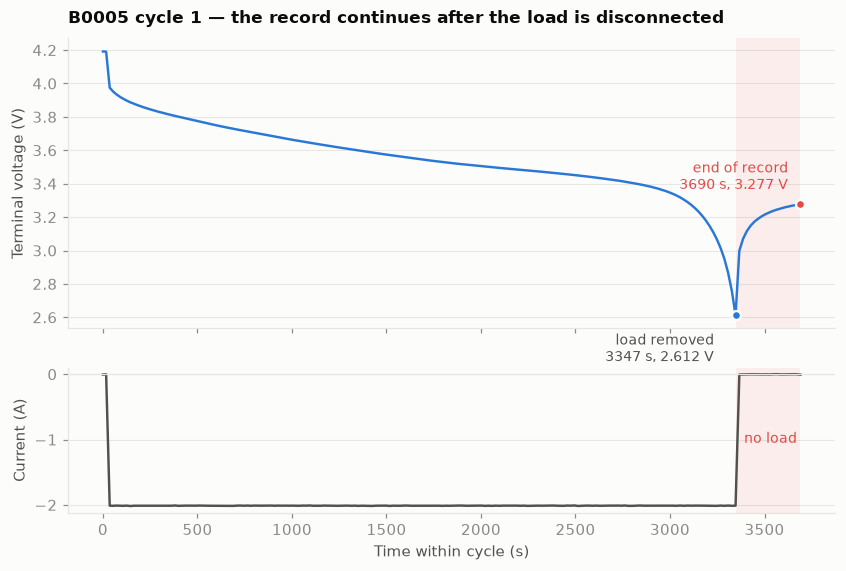

In [9]:
i = np.asarray(d["Current_measured"], float)
active = np.abs(i) > CFG["ingestion"]["active_current_a"]
last = np.where(active)[0][-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.18})

ax1.axvspan(t[last], t[-1], color=ACCENT_BAD, alpha=0.08, lw=0)
ax1.plot(t, v, color=SERIES["B0005"])
ax1.scatter([t[last]], [v[last]], s=34, color=SERIES["B0005"], zorder=5,
            edgecolor=SURFACE, linewidth=1.5)
ax1.scatter([t[-1]], [v[-1]], s=34, color=ACCENT_BAD, zorder=5,
            edgecolor=SURFACE, linewidth=1.5)
ax1.annotate(f"load removed\n{t[last]:.0f} s, {v[last]:.3f} V",
             (t[last], v[last]), textcoords="offset points", xytext=(-14, -30),
             ha="right", fontsize=9, color=INK2)
ax1.annotate(f"end of record\n{t[-1]:.0f} s, {v[-1]:.3f} V",
             (t[-1], v[-1]), textcoords="offset points", xytext=(-8, 10),
             ha="right", fontsize=9, color=ACCENT_BAD)
style(ax1, "B0005 cycle 1 — the record continues after the load is disconnected",
      ylabel="Terminal voltage (V)")

ax2.axvspan(t[last], t[-1], color=ACCENT_BAD, alpha=0.08, lw=0)
ax2.plot(t, i, color=INK2)
ax2.axhline(0, color=GRID, lw=0.8)
style(ax2, None, "Time within cycle (s)", "Current (A)")
ax2.text(t[last] + 45, -1.05, "no load", fontsize=9, color=ACCENT_BAD)
plt.show()

### How to read it

Follow the **bottom panel first**. Current sits at −2 A for most of the cycle: the cell
is delivering a constant 2 A into the load, exactly as the protocol specifies. Then at
about 3350 s it snaps to zero and stays there. The load has been disconnected.

Now look at the **top panel** over that same region. Voltage falls steadily through the
discharge — the normal shape, steep at the start, a long plateau, then a sharp knee at
the end — reaches 2.612 V at the moment the load drops, and then **climbs back up** to
3.277 V.

That recovery is not a measurement error. With no current flowing there is no IR drop
across the cell's internal resistance, and lithium concentration gradients that built up
inside the electrode particles during discharge begin to even out. The terminal voltage
relaxes toward the cell's true open-circuit value.

### Why it matters

The naive reading of this record gives two wrong numbers:

- **Duration** 3690 s instead of 3347 s — over 10% too long.
- **End voltage** 3.277 V instead of 2.612 V — not the cut-off at all, but a rest voltage.

And the error is *systematic*. It appears on every cycle of every cell, always in the
same direction, so it would never look anomalous. Energy, duration and end-voltage
features would all be quietly biased.

In [10]:
print(f"record duration      {t[-1]:8.0f} s")
print(f"active discharge     {t[last]:8.0f} s")
print(f"relaxation tail      {t[-1]-t[last]:8.0f} s  ({(t[-1]-t[last])/t[-1]*100:.1f}% of record)")
print(f"voltage at cut-off   {v[last]:8.3f} V")
print(f"voltage at end       {v[-1]:8.3f} V   <- NOT the cut-off")
print(f"recovery             {v[-1]-v[last]:8.3f} V")

record duration          3690 s
active discharge         3347 s
relaxation tail           343 s  (9.3% of record)
voltage at cut-off      2.612 V
voltage at end          3.277 V   <- NOT the cut-off
recovery                0.665 V


### How the pipeline handles it

Every discharge aggregate is computed over the **active segment** — samples where
|current| > 0.5 A. The tail is not thrown away, though. Voltage recovery depends on
internal resistance, and internal resistance rises as a cell ages, so the recovery
magnitude is itself a health indicator. It is kept as `v_recovery_v`.

The two charts below confirm both halves of that: the tail is a consistent fraction of
every record, and recovery grows monotonically with age.

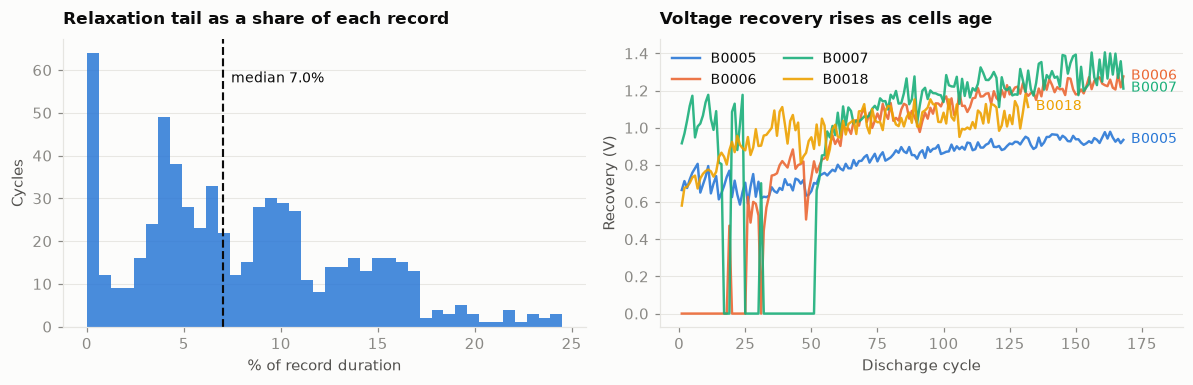

In [11]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11, 3.6))

frac = cyc["relax_duration_s"] / cyc["record_duration_s"] * 100
axl.hist(frac.dropna(), bins=40, color=SERIES["B0005"], alpha=0.85)
axl.axvline(frac.median(), color=INK, lw=1.4, ls="--")
axl.text(frac.median() + 0.4, axl.get_ylim()[1]*0.85,
         f"median {frac.median():.1f}%", fontsize=9, color=INK)
style(axl, "Relaxation tail as a share of each record", "% of record duration", "Cycles")

for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    axr.plot(g.cycle_id, g.v_recovery_v, color=SERIES[b], label=b, alpha=0.9)
    axr.annotate(b, (g.cycle_id.iloc[-1], g.v_recovery_v.iloc[-1]),
                 textcoords="offset points", xytext=(5, -2), fontsize=9, color=SERIES[b])
style(axr, "Voltage recovery rises as cells age", "Discharge cycle", "Recovery (V)")
axr.legend(loc="upper left", fontsize=9, ncols=2)
axr.set_xlim(right=axr.get_xlim()[1] * 1.08)
plt.tight_layout(); plt.show()

**Left:** the tail is tightly concentrated around 9–12% of each record. It is not an
occasional glitch — it is how every record is structured.

**Right:** recovery climbs from roughly 0.67 V to 0.94 V for B0005 over its life. A cell
with higher internal resistance sags further under load and therefore rebounds further
when the load is removed. This is a genuine degradation signal that a naive parser would
have discarded as trailing junk.

---

# 5. Finding 2 — operation ordering differs between batteries

### What we expected

Charge, discharge and impedance repeat throughout the file. The tempting shortcut is to
assume a fixed repeating pattern and pair records by stride — "every discharge is
preceded by a charge two positions back".

### Why it needs checking

Pairing matters because the charge-phase features (`cc_duration_s` and friends) come from
a *different record* than the discharge they describe. Get the pairing wrong and you
attribute one cycle's charge behaviour to another cycle's capacity — a subtle,
silent corruption that would still produce plausible-looking plots.

### The plot

Each battery's first 40 operations, drawn as three lanes. A block in a lane means that
operation type occurred at that position.

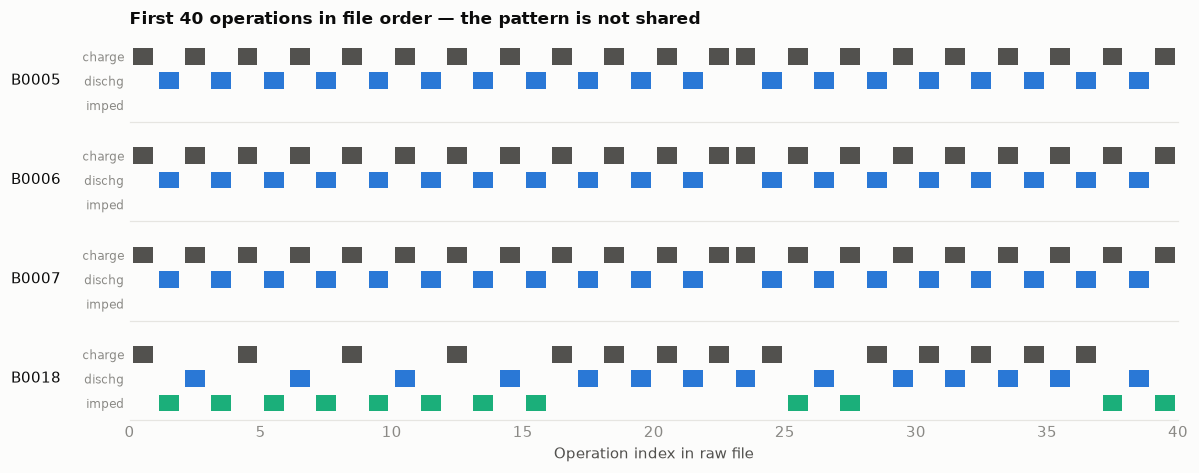

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(11, 4.4), sharex=True)
LANE = {"charge": (2, INK2), "discharge": (1, SERIES["B0005"]), "impedance": (0, SERIES["B0007"])}

for ax, b in zip(axes, BATTERIES):
    mm = loadmat(str(RAW / f"{b}.mat"), simplify_cells=True)
    tys = [str(o["type"]) for o in np.atleast_1d(mm[b]["cycle"])][:40]
    for k, ty in enumerate(tys):
        lane, colr = LANE[ty]
        ax.add_patch(plt.Rectangle((k + 0.12, lane - 0.34), 0.76, 0.68, color=colr, lw=0))
    ax.set_ylim(-0.7, 2.7); ax.set_xlim(0, 40)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["imped", "dischg", "charge"], fontsize=8)
    ax.set_ylabel(b, rotation=0, ha="right", va="center", fontsize=10, color=INK, labelpad=14)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

axes[0].set_title("First 40 operations in file order — the pattern is not shared",
                  color=INK, loc="left")
axes[-1].set_xlabel("Operation index in raw file")
plt.tight_layout(); plt.show()

### How to read it

Compare the bottom row against the three above it.

**B0005, B0006 and B0007** are identical: a strict charge → discharge alternation, with
the impedance lane completely empty for the first 40 operations.

**B0018** is visibly different. Its impedance lane is populated from the very start, and
it runs a four-operation pattern — charge, impedance, discharge, impedance — for roughly
the first 16 operations before settling into the simpler alternation.

A stride-based pairing rule tuned on B0005 would mis-align every early B0018 cycle.

### How the pipeline handles it

All pairing is **positional**, using `merge_asof` on `op_index`: each discharge takes the
most recent preceding charge, whatever the stride. It is direction-aware, so it also
enforces the leakage rule — a discharge can only ever be matched to a charge that came
*before* it.

### A consequence: impedance availability differs sharply

In [13]:
print("Cycles with no impedance available yet (nothing earlier to carry forward):")
print(cyc[cyc.re_ohm.isna()].groupby("battery_id").cycle_id.agg(
    n_cycles="size", last_cycle="max").to_string())
print()
print("Once available, how stale is the joined measurement (in raw operations)?")
print(cyc.groupby("battery_id").impedance_age_ops.agg(["mean", "median", "max"]).round(1).to_string())
print()
print("Leakage guard -- a negative staleness would mean a FUTURE measurement was")
print("joined backward in time. Minimum across all rows:", cyc.impedance_age_ops.min())

Cycles with no impedance available yet (nothing earlier to carry forward):
            n_cycles  last_cycle
battery_id                      
B0005             19          19
B0006             19          19
B0007             19          19

Once available, how stale is the joined measurement (in raw operations)?
            mean  median   max
battery_id                    
B0005        1.2     1.0   5.0
B0006        1.2     1.0   5.0
B0007        1.2     1.0   5.0
B0018        4.6     4.0  13.0

Leakage guard -- a negative staleness would mean a FUTURE measurement was
joined backward in time. Minimum across all rows: 1.0


Two opposite problems, for opposite reasons:

- **B0005/6/7** record no impedance until after cycle 19, so their first 19 cycles have
  nothing to carry forward — 57 null rows. Backward-fill cannot fill a *leading* gap.
- **B0018** has impedance from cycle 1 but measures it far less often afterwards, so its
  joined values go stale by up to 13 operations.

Phase 6 has to make a decision here: drop those 57 cycles, impute with an explicit
missingness indicator, or restrict impedance features to cycle ≥ 20. All three are
defensible; silently leaving nulls in a tree model is not.

---

# 6. Findings 3 & 4 — partial and aborted charge records

### Why charge records deserve scrutiny

CC-charge duration is among the most useful health indicators available, because it
shortens predictably as a cell ages. Two effects drive this: an aged cell holds less
charge so it fills sooner, and its higher internal resistance means a larger IR drop, so
the *measured* terminal voltage hits 4.2 V while the electrode is still below it. Both
end the CC phase early.

That sensitivity cuts both ways. A short CC phase caused by a **logging failure** is
numerically indistinguishable from a short CC phase caused by **degradation**. If a
malformed record is not flagged, the model learns it as a health signal.

### The plot

CC duration against cycle number, one panel per battery. Flagged records are marked in
red — circles for partial charges, triangles for aborted ones.

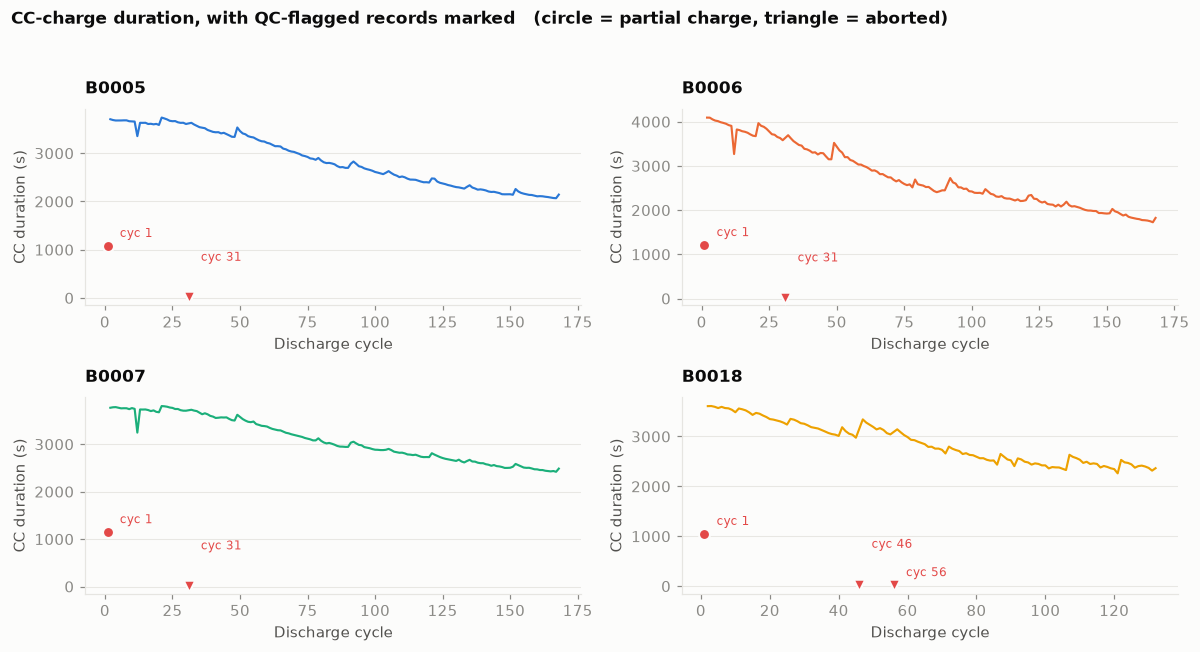

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

for ax, b in zip(axes.ravel(), BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    ok = g[~g.qc_charge_aborted & ~g.qc_charge_partial]
    ax.plot(ok.cycle_id, ok.cc_duration_s, color=SERIES[b], lw=1.4)

    part, abrt = g[g.qc_charge_partial], g[g.qc_charge_aborted]
    ax.scatter(part.cycle_id, part.cc_duration_s, s=52, color=ACCENT_BAD,
               zorder=5, edgecolor=SURFACE, linewidth=1.4, marker="o")
    ax.scatter(abrt.cycle_id, abrt.cc_duration_s, s=58, color=ACCENT_BAD,
               zorder=5, edgecolor=SURFACE, linewidth=1.4, marker="v")
    flagged = pd.concat([part, abrt]).sort_values("cycle_id")
    for k, (_, r) in enumerate(flagged.iterrows()):
        dy = 6 if k % 2 == 0 else 24   # upward stagger; markers sit near y=0
        ax.annotate(f"cyc {int(r.cycle_id)}", (r.cycle_id, r.cc_duration_s),
                    textcoords="offset points", xytext=(8, dy), fontsize=8, color=ACCENT_BAD)
    style(ax, b, "Discharge cycle", "CC duration (s)")
    ax.set_ylim(bottom=-150)

fig.suptitle("CC-charge duration, with QC-flagged records marked   "
             "(circle = partial charge, triangle = aborted)",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

### How to read it

The **blue/orange/green/yellow line** is the real signal: a clear downward trend in every
panel. CC duration falls from roughly 3700 s to 2100 s for B0005 across its life. That is
degradation, and it is exactly what the physics predicts.

Now the red marks, which sit far below that trend:

**Circles at cycle 1** — one on every battery. These are not degraded cells; they are
*partial charges*. The experiment began with cells already partly charged, so the first
charge only needed to deliver about 0.8 Ah against a ~1.9 Ah norm.

This is the dangerous one. At cycle 1 a healthy cell shows a *short* CC phase — precisely
the pattern that otherwise means "worn out". Left unflagged it inverts the indicator's
meaning, at the very cycle that other features are normalised against.

**Triangles near zero** — records with essentially no charge at all. Note where they
fall: **B0005, B0006 and B0007 all fail at exactly cycle 31**. Three cells do not
independently fail on the same cycle. That is one testbed interruption affecting all
cells at once, which also tells us these experiments ran in parallel (confirmed
independently in Section 8).

In [15]:
print("Finding 3 -- partial charges (charge_ah < 0.8 x capacity_ah):")
print(cyc[cyc.qc_charge_partial][
    ["battery_id", "cycle_id", "charge_ah", "capacity_ah", "cc_duration_s"]
].round(2).to_string(index=False))

print()
print("Finding 4 -- aborted charges (cc_duration < 60 s or charge_ah < 0.1 Ah):")
print(cyc[cyc.qc_charge_aborted][
    ["battery_id", "cycle_id", "cc_duration_s", "charge_ah"]
].round(2).to_string(index=False))

print()
print("For scale, CC duration on unflagged cycles:")
print(cyc[~cyc.qc_any].groupby("battery_id").cc_duration_s.describe()[
    ["min", "50%", "max"]].round(0).to_string())

Finding 3 -- partial charges (charge_ah < 0.8 x capacity_ah):
battery_id  cycle_id  charge_ah  capacity_ah  cc_duration_s
     B0005         1       0.78         1.86        1072.95
     B0006         1       0.85         2.04        1204.59
     B0007         1       0.81         1.89        1141.09
     B0018         1       0.78         1.86        1042.06

Finding 4 -- aborted charges (cc_duration < 60 s or charge_ah < 0.1 Ah):
battery_id  cycle_id  cc_duration_s  charge_ah
     B0005        31           9.03       0.01
     B0006        31           9.03       0.04
     B0007        31           9.03       0.03
     B0018        46          32.39       0.17
     B0018        56          15.44       0.03

For scale, CC duration on unflagged cycles:
               min     50%     max
battery_id                        
B0005       2067.0  2785.0  3739.0
B0006       1726.0  2514.0  4093.0
B0007       2419.0  2950.0  3800.0
B0018       2261.0  2792.0  3610.0


### A correction worth recording

The first version of the partial-charge rule flagged a cycle when
`charge_ah < 0.5 × (that battery's median charge_ah)`. It caught **1 of the 4** known
cases.

The reason is instructive: delivered charge *declines as the cell ages*, so the
whole-trajectory median drifts downward toward the value being tested against. The
threshold moved with the very degradation it was supposed to be independent of.

The replacement is physical and self-normalising — a full charge must deliver at least
as much as the following discharge extracts, so `charge_ah < 0.8 × capacity_ah`. It
catches all 4 with no false positives across the other 632 cycles.

There is a second reason the original was wrong. A whole-trajectory median is not
available at prediction time, so the rule was also a **leakage pattern**. It happened to
sit in QC code rather than in a feature, but the same instinct applied in Phase 6 would
have produced a leaky feature.

---

# 7. Finding 5 — early-life discharges overshoot the cut-off  *(open)*

**This finding is flagged, not resolved.** It is carried into Phase 4 as an open question.

### What we checked

Each cell has a documented discharge cut-off voltage. A simple validation: does the
measured minimum voltage of each discharge actually match it?

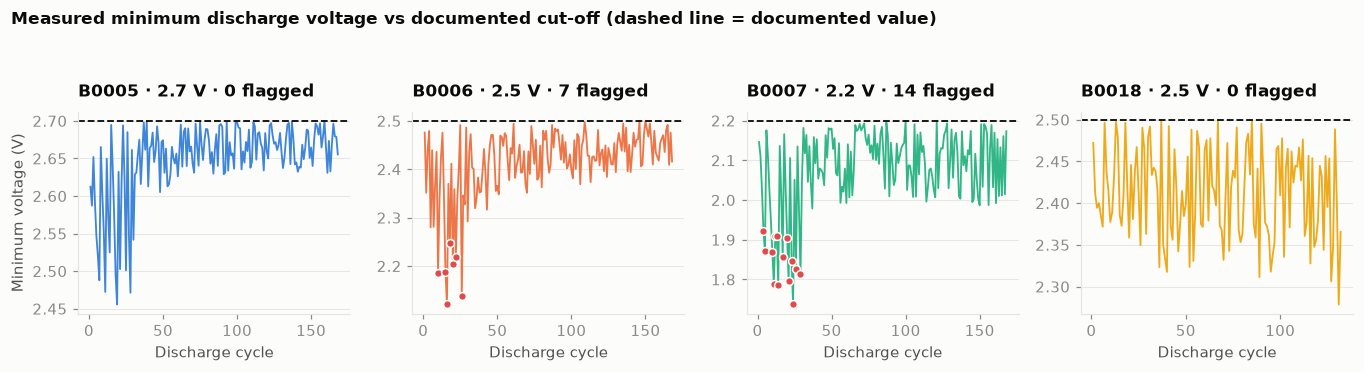

            documented  vmin_median  vmin_lowest  n_flagged
battery_id                                                 
B0005              2.7        2.660        2.456          0
B0006              2.5        2.429        2.121          7
B0007              2.2        2.102        1.737         14
B0018              2.5        2.415        2.279          0


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.4))

for ax, b in zip(axes, BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    nominal = CFG["cutoff_voltage_v"][b]
    bad = g[g.qc_cutoff_mismatch]
    ax.plot(g.cycle_id, g.v_min_v, color=SERIES[b], lw=1.2, alpha=0.9)
    ax.scatter(bad.cycle_id, bad.v_min_v, s=26, color=ACCENT_BAD, zorder=5,
               edgecolor=SURFACE, linewidth=1.0)
    ax.axhline(nominal, color=INK, lw=1.2, ls="--")
    # Cut-off value goes in the title: an in-panel label collides with it.
    # Kept terse and downsized so four titles fit side by side.
    style(ax, f"{b} · {nominal} V · {len(bad)} flagged", "Discharge cycle",
          "Minimum voltage (V)" if b == "B0005" else None)
    ax.title.set_fontsize(9.5)

fig.suptitle("Measured minimum discharge voltage vs documented cut-off "
             "(dashed line = documented value)",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

print(cyc.groupby("battery_id").agg(
    documented=("cutoff_nominal_v", "first"),
    vmin_median=("v_min_v", "median"),
    vmin_lowest=("v_min_v", "min"),
    n_flagged=("qc_cutoff_mismatch", "sum"),
).round(3).to_string())

### How to read it

The dashed line is the documented cut-off; the coloured line is what was actually
measured each cycle. Two distinct effects are visible.

**1. A small systematic undershoot — benign.** In every panel the coloured line sits
slightly *below* the dashed line, by 0.04–0.10 V. Samples arrive every 9–19 s, so the
controller detects the cut-off one sample after the cell has already passed it. Expected
behaviour for a sampled system.

**2. A large early-life overshoot — not benign.** Look at the left-hand end of the
**B0006** and **B0007** panels. A cluster of red points sits far below the line:
B0006 cycles 10–26 reach a median 2.188 V against a 2.5 V cut-off, and B0007 cycles 4–29
reach 1.852 V against 2.2 V. That is roughly 0.3 V deeper than specified.

B0005 and B0018 show nothing comparable.

### Why this is left open

A deeper discharge extracts more charge. If those cycles were discharged 0.3 V below
specification, their recorded `capacity_ah` may **overstate** the cell's true health — not
because the cell was healthier, but because it was drained harder.

That matters because it lands in early life, which is exactly where the SOH reference
point and the early-prediction experiments live. The pipeline flags it
(`qc_cutoff_mismatch`) but does not correct it, because the right correction depends on
whether Phase 4 finds a visible distortion in the capacity trajectory over precisely
those cycle ranges. Inventing a correction before establishing the effect would be
guesswork.

---

# 8. Finding 6 — identical telemetry volumes are real, not a bug

### The suspicion

When the build first ran, B0005, B0006 and B0007 each reported **exactly 591,458**
telemetry rows. Identical counts across three separate files is exactly what a copy-paste
bug looks like — reading the same file three times, or overwriting a dictionary key in a
loop.

That had to be ruled out before trusting anything downstream.

### The test

If the three frames hold the same data, their summary statistics will be identical too.
If they merely have the same *shape*, the values will differ.

In [17]:
chk = tel.groupby("battery_id").agg(
    rows=("voltage_v", "size"),
    voltage_sum=("voltage_v", "sum"),
    voltage_mean=("voltage_v", "mean"),
    current_sum=("current_a", "sum"),
).round(4)
print(chk.to_string())

trio = ["B0005", "B0006", "B0007"]
print()
print(f"identical row counts : {chk.loc[trio,'rows'].nunique() == 1}")
print(f"identical values     : {chk.loc[trio,'voltage_sum'].nunique() == 1}   <- must be False")

              rows   voltage_sum  voltage_mean  current_sum
battery_id                                                 
B0005       591458  2.427311e+06        4.1039  218487.1490
B0006       591458  2.427482e+06        4.1042  212536.3454
B0007       591458  2.424825e+06        4.0997  228879.3213
B0018       314676  1.282809e+06        4.0766   96310.2285

identical row counts : True
identical values     : False   <- must be False


### Interpretation

Row counts match exactly; voltage sums differ in the fourth significant figure
(2,427,311 vs 2,427,482 vs 2,424,825). The data is genuinely different — same shape, same
sampling, different cells.

The explanation is the testbed. These three cells were cycled **simultaneously on the
same rig**, under one protocol, with synchronised logging, so they accumulate the same
number of samples. It is independent confirmation of what the aborted charges in Section
6 implied: all three failing at cycle 31 was one shared interruption.

B0018 differs on every count because it was a shorter, separately-run experiment.

Worth noting as a general habit: a suspicious coincidence is worth two minutes of
checking. This one turned out to be benign, but the cost of *not* checking would have
been three identical batteries silently inflating every cross-validation score.

---

# 9. Targets, regeneration and validation

## 9.1 SOH trajectories and EOL

The two panels answer different questions. The left shows **absolute** degradation and
where each cell crosses the EOL threshold. The right re-plots the same data against
*fraction of life* — which asks whether the cells degrade the **same way** once you
account for them having different lifetimes.

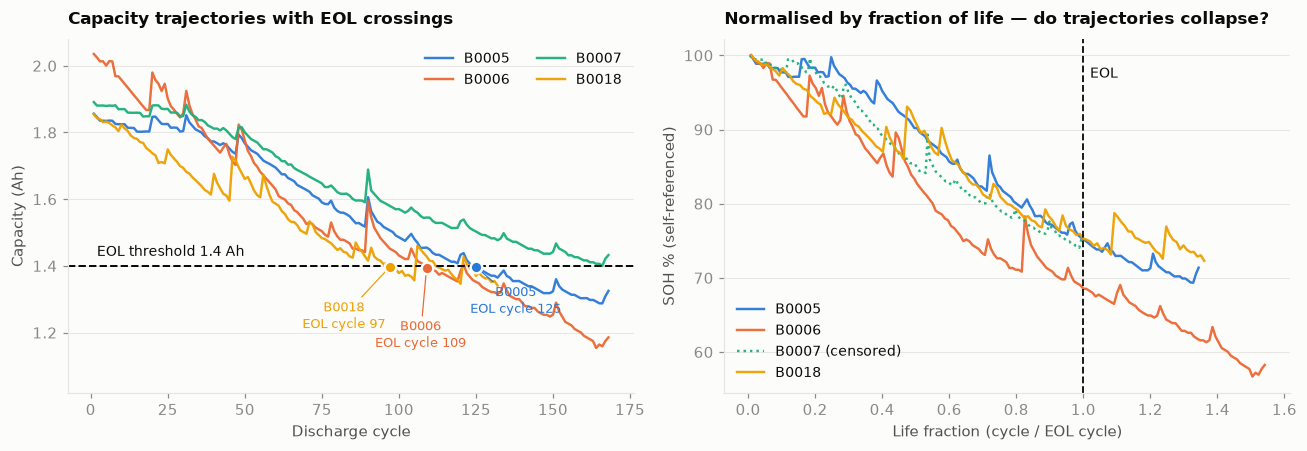

In [18]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.2))
eol_cap = CFG["targets"]["eol_capacity_ah"]

EOL_LABEL = {"B0018": (-30, -40), "B0006": (-4, -52), "B0005": (26, -30)}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    axl.plot(g.cycle_id, g.capacity_ah, color=SERIES[b], label=b, alpha=0.95)
    e = g.eol_cycle.iloc[0]
    if pd.notna(e):
        row = g[g.cycle_id == int(e)].iloc[0]
        axl.scatter([row.cycle_id], [row.capacity_ah], s=58, color=SERIES[b],
                    zorder=6, edgecolor=SURFACE, linewidth=1.6)
        axl.annotate(f"{b}\nEOL cycle {int(e)}", (row.cycle_id, row.capacity_ah),
                     textcoords="offset points", xytext=EOL_LABEL[b], fontsize=8.5,
                     color=SERIES[b], ha="center",
                     arrowprops=dict(arrowstyle="-", color=SERIES[b], lw=0.8,
                                     shrinkA=0, shrinkB=4))
axl.axhline(eol_cap, color=INK, lw=1.3, ls="--")
axl.text(2, eol_cap + 0.03, f"EOL threshold {eol_cap} Ah", fontsize=9, color=INK)
style(axl, "Capacity trajectories with EOL crossings", "Discharge cycle", "Capacity (Ah)")
axl.set_ylim(bottom=1.02)
axl.legend(loc="upper right", fontsize=9, ncols=2)

for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    if g.is_censored.iloc[0]:
        axr.plot(g.cycle_id / g.cycle_id.max(), g.soh_pct_self, color=SERIES[b],
                 ls=":", label=f"{b} (censored)", alpha=0.95)
    else:
        axr.plot(g.life_fraction, g.soh_pct_self, color=SERIES[b], label=b, alpha=0.95)
axr.axvline(1.0, color=INK, lw=1.2, ls="--")
axr.text(1.02, 97, "EOL", fontsize=9, color=INK)
style(axr, "Normalised by fraction of life — do trajectories collapse?",
      "Life fraction (cycle / EOL cycle)", "SOH % (self-referenced)")
axr.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

### How to read the left panel

All four cells start between 1.86 and 2.04 Ah and decline. The decline is **not smooth** —
every trajectory is visibly jagged, with repeated upward jumps. That is capacity
regeneration, covered next.

Cells cross the 1.4 Ah line at very different times: **B0018 at cycle 97, B0006 at 109,
B0005 at 125**. B0006 starts highest and dies first, so initial capacity is a poor
predictor of lifetime — which is precisely why this problem needs a model rather than a
lookup.

**B0007 (green) never crosses the line.** Its lowest capacity is 1.4005 Ah — it comes
within 0.5 mAh of the threshold and the experiment stops. It is right-censored: we know
its life exceeds 168 cycles but not by how much.

### How to read the right panel

Here the x-axis is normalised: 1.0 means "this cell's EOL". If degradation followed one
universal law, the curves would collapse onto a single line.

They partly do. The three uncensored cells fall within a band of roughly 5–8 percentage
points of SOH for most of their lives — close, but distinguishable. **B0006 (orange) sits
consistently lowest**, degrading faster in relative terms as well as absolute.

That band width is the honest answer to "how well will a model generalise to an unseen
cell?" Not perfectly, but not hopelessly either — and with four cells, that judgement is
about all the data can support.

B0007 is dotted and plotted against its own cycle range, since it has no EOL to normalise
by. Note it tracks the top of the band, consistent with being the slowest to degrade.

In [19]:
print(cyc.groupby("battery_id").agg(
    cap_first=("capacity_ah", "first"),
    cap_min=("capacity_ah", "min"),
    soh0_self=("soh_pct_self", "first"),
    soh0_rated=("soh_pct_rated", "first"),
    eol_cycle=("eol_cycle", "first"),
    eol_first_touch=("eol_first_touch_cycle", "first"),
    censored=("is_censored", "first"),
).round(3).to_string())

print()
print("B0007 margin to EOL: %.6f Ah" % (cyc[cyc.battery_id=='B0007'].capacity_ah.min() - 1.4))
print("Rows carrying a usable RUL label: %d of %d" % (cyc.rul_valid.sum(), len(cyc)))
print()
print("Note: eol_cycle == eol_first_touch_cycle for all three uncensored cells.")
print("The sustained-crossing rule did not change the answer on this data. It is a")
print("safeguard, and its behaviour is proven by unit test rather than by these cells.")

            cap_first  cap_min  soh0_self  soh0_rated  eol_cycle  eol_first_touch  censored
battery_id                                                                                 
B0005           1.856    1.287      100.0      92.824      125.0            125.0     False
B0006           2.035    1.154      100.0     101.767      109.0            109.0     False
B0007           1.891    1.400      100.0      94.553        NaN              NaN      True
B0018           1.855    1.341      100.0      92.750       97.0             97.0     False

B0007 margin to EOL: 0.000455 Ah
Rows carrying a usable RUL label: 331 of 636

Note: eol_cycle == eol_first_touch_cycle for all three uncensored cells.
The sustained-crossing rule did not change the answer on this data. It is a
safeguard, and its behaviour is proven by unit test rather than by these cells.


Two consequences for modelling, both uncomfortable and both real:

- **SOH** has 4 cells to learn from.
- **RUL** has 3, because B0007 carries no label. 168 of 636 rows have no target.

No modelling choice fixes this. It has to be stated wherever a generalisation claim is
made.

## 9.2 Capacity regeneration

Those jagged upward jumps are the dataset's most distinctive feature, and the easiest
thing to mistake for sensor noise.

They are not noise. When a cell rests, internal lithium concentration gradients even out
and some interfacial effects partially relax, so the next discharge can extract more
charge before hitting the cut-off. The cell has **not** recovered lost lithium — nothing
about the degradation reversed. What recovered is the cell's ability to deliver what it
still has.

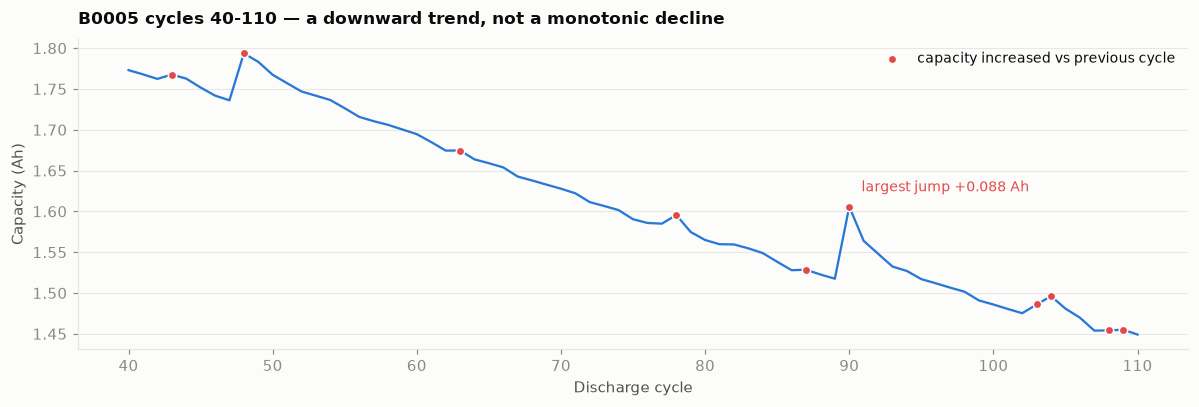

battery_id  n_steps  n_regen  regen_pct  regen_max_ah  regen_mean_ah  regen_max_pp_soh
     B0005      167       36       21.6        0.0883         0.0115              4.76
     B0006      167       27       16.2        0.1519         0.0287              7.46
     B0007      167       47       28.1        0.0982         0.0075              5.19
     B0018      131       21       16.0        0.1312         0.0319              7.08


In [20]:
g = cyc[cyc.battery_id == "B0005"].sort_values("cycle_id")
lo, hi = 40, 110
w = g[(g.cycle_id >= lo) & (g.cycle_id <= hi)]
dif = w.capacity_ah.diff()
up = w[dif > 0]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(w.cycle_id, w.capacity_ah, color=SERIES["B0005"], lw=1.5)
ax.scatter(up.cycle_id, up.capacity_ah, s=30, color=ACCENT_BAD, zorder=5,
           edgecolor=SURFACE, linewidth=1.0, label="capacity increased vs previous cycle")
big = dif.idxmax()
ax.annotate(f"largest jump +{dif.max():.3f} Ah",
            (w.loc[big, "cycle_id"], w.loc[big, "capacity_ah"]),
            textcoords="offset points", xytext=(8, 10), fontsize=9, color=ACCENT_BAD)
style(ax, f"B0005 cycles {lo}-{hi} — a downward trend, not a monotonic decline",
      "Discharge cycle", "Capacity (Ah)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

print(regen.to_string(index=False))

### How to read it

Zoomed into 70 cycles of B0005, the sawtooth structure is unmistakable: a run of
declining cycles, then a jump back up, repeatedly. Red dots mark every cycle that
measured *higher* than the one before.

The summary table gives the scale. Between **16% and 28%** of all cycle-to-cycle steps go
upward, and the largest single jump is worth **7.5 percentage points of SOH**. Sensor
noise on these measurements is a fraction of a percent, so this is one to two orders of
magnitude larger than noise.

### Three consequences

1. **Do not "clean" it.** Deleting these points is the standard way to produce a
   suspiciously smooth trajectory and an unrealistically good model. They are real
   measurements of real behaviour.
2. **Monotonicity assumptions break.** Any feature or model that assumes SOH only
   decreases is contradicted by a fifth of the data.
3. **The EOL rule needs care.** A cell can dip below 1.4 Ah and climb back out, so EOL
   requires a *sustained* crossing — the rule described in Section 3.2.

### Is rest the driver?

If regeneration is a relaxation effect, longer rests before a cycle should produce bigger
jumps. Worth testing rather than assuming.

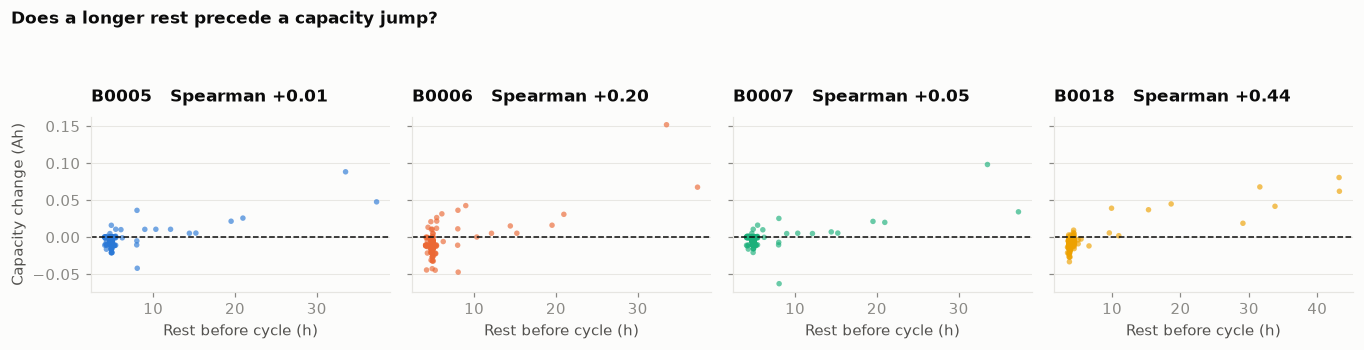

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2), sharey=True)
for ax, b in zip(axes, BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id").copy()
    g["delta"] = g.capacity_ah.diff()
    s = g.dropna(subset=["delta", "rest_before_h"])
    s = s[s.rest_before_h < s.rest_before_h.quantile(0.99)]
    ax.scatter(s.rest_before_h, s.delta, s=13, color=SERIES[b], alpha=0.65, edgecolor="none")
    ax.axhline(0, color=INK, lw=1.0, ls="--")
    r = s.rest_before_h.corr(s.delta, method="spearman")
    style(ax, f"{b}   Spearman {r:+.2f}", "Rest before cycle (h)",
          "Capacity change (Ah)" if b == "B0005" else None)
fig.suptitle("Does a longer rest precede a capacity jump?",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

The answer is **partly, and inconsistently**. Spearman correlations are positive but
modest, and they vary noticeably between cells. Most points cluster at short rests with
small changes; the long-rest cycles do skew positive, but the relationship is far from
deterministic.

Stated honestly: rest duration is a *contributing* factor, not a clean predictor. Phase 4
should examine it jointly with cell age, since the size of an achievable rebound plausibly
depends on how degraded the cell already is. `rest_before_h` is retained as a feature —
it is causally available at prediction time, which many alternatives are not.

## 9.3 Physical validation — is the parser actually right?

Unit tests confirm the code does what it was written to do. They cannot confirm the
*interpretation* of the raw fields is correct — a parser that mislabels a column will
pass its tests happily.

The stronger check is physical. Battery science predicts specific relationships. None of
them were fitted or targeted; they either emerge from correctly parsed data or they
don't:

- **CC duration should shorten** as capacity falls (less charge to store, larger IR drop).
- **CV duration should lengthen** to compensate.
- **Rct should rise** as capacity falls (thicker SEI, degraded interfaces).

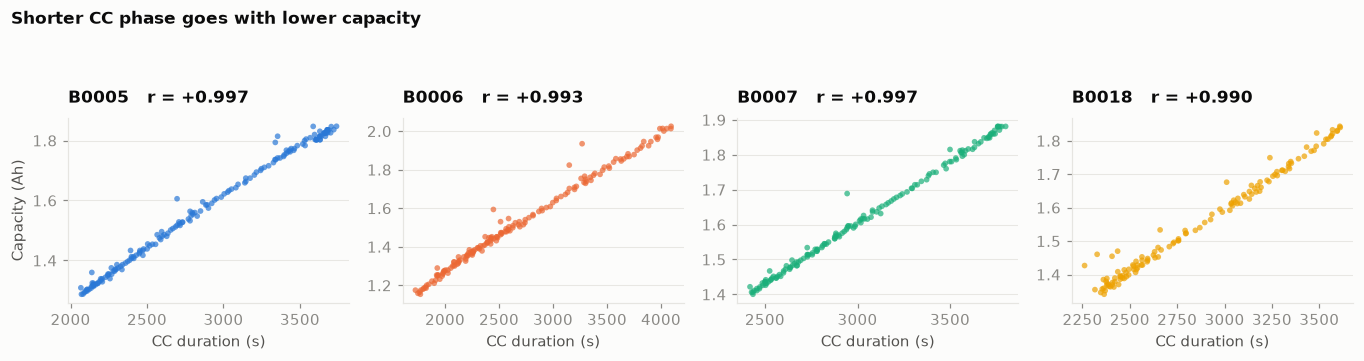

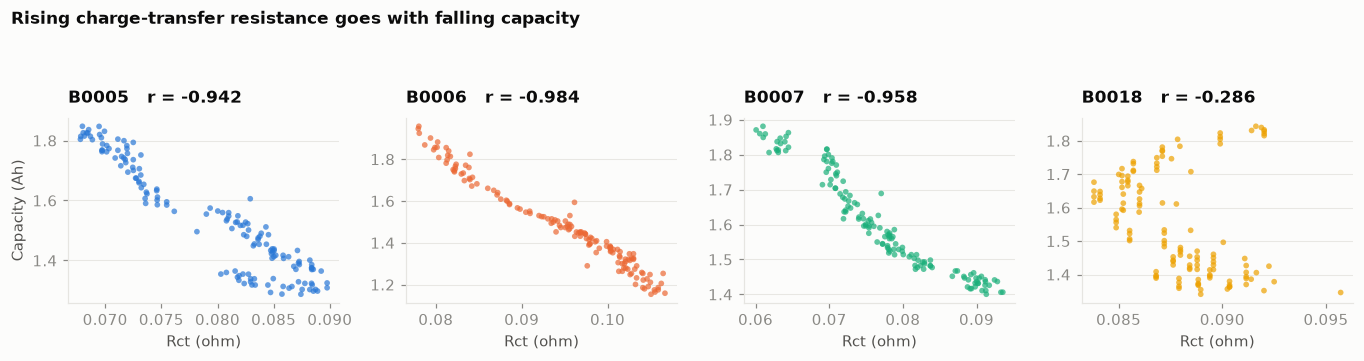

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3))
for ax, b in zip(axes, BATTERIES):
    g = cyc[(cyc.battery_id == b) & ~cyc.qc_any]
    ax.scatter(g.cc_duration_s, g.capacity_ah, s=14, color=SERIES[b], alpha=0.7,
               edgecolor="none")
    r = g.cc_duration_s.corr(g.capacity_ah)
    style(ax, f"{b}   r = {r:+.3f}", "CC duration (s)",
          "Capacity (Ah)" if b == "B0005" else None)
fig.suptitle("Shorter CC phase goes with lower capacity",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3))
for ax, b in zip(axes, BATTERIES):
    g = cyc[(cyc.battery_id == b) & ~cyc.qc_any].dropna(subset=["rct_ohm"])
    ax.scatter(g.rct_ohm, g.capacity_ah, s=14, color=SERIES[b], alpha=0.7, edgecolor="none")
    r = g.rct_ohm.corr(g.capacity_ah)
    style(ax, f"{b}   r = {r:+.3f}", "Rct (ohm)",
          "Capacity (Ah)" if b == "B0005" else None)
fig.suptitle("Rising charge-transfer resistance goes with falling capacity",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

In [23]:
rows = []
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    rows.append({
        "battery": b,
        "cycle~cc_dur": g.cycle_id.corr(g.cc_duration_s),
        "cycle~cv_dur": g.cycle_id.corr(g.cv_duration_s),
        "cc_dur~capacity": g.cc_duration_s.corr(g.capacity_ah),
        "rct~capacity": g.rct_ohm.corr(g.capacity_ah),
        "re~capacity": g.re_ohm.corr(g.capacity_ah),
        "v_recovery~capacity": g.v_recovery_v.corr(g.capacity_ah),
    })
print(pd.DataFrame(rows).set_index("battery").round(3).to_string())
print()
print("Expected: cc_dur negative with cycle, cv_dur positive with cycle,")
print("cc_dur positive with capacity, resistance negative with capacity.")

         cycle~cc_dur  cycle~cv_dur  cc_dur~capacity  rct~capacity  re~capacity  v_recovery~capacity
battery                                                                                             
B0005          -0.821         0.836            0.822        -0.943       -0.885               -0.937
B0006          -0.863         0.809            0.862        -0.983       -0.971               -0.916
B0007          -0.748         0.829            0.747        -0.960       -0.952               -0.695
B0018          -0.619         0.540            0.586        -0.237       -0.784               -0.846

Expected: cc_dur negative with cycle, cv_dur positive with cycle,
cc_dur positive with capacity, resistance negative with capacity.


### Interpretation

Every predicted sign holds, and for three of four cells the magnitudes are strong:
CC duration correlates **+0.75 to +0.86** with capacity, and Rct **−0.94 to −0.98**.

These relationships were not engineered. They come from correctly identifying which raw
field is which, segmenting the CC and CV phases at the right sample, and joining
impedance to the right cycle. Getting any of those wrong would have degraded or destroyed
the correlations. This is the best evidence available that the parser is not just
self-consistent but actually correct.

The scatter plots add something the correlation table hides: the relationship is
**not linear**. Points curve, and cluster at high capacity. Linear correlation understates
a monotone-but-curved relationship, which is exactly why Phase 4 should screen indicators
with **Spearman as well as Pearson**.

And one row does not fit.

## 9.4 B0018 does not behave like the others

Reading down the table, B0018 is weaker on every measure, and `rct~capacity` collapses
from about −0.95 to **−0.24**. With four cells, one atypical cell is 25% of the dataset —
and in leave-one-battery-out cross-validation it becomes an entire fold.

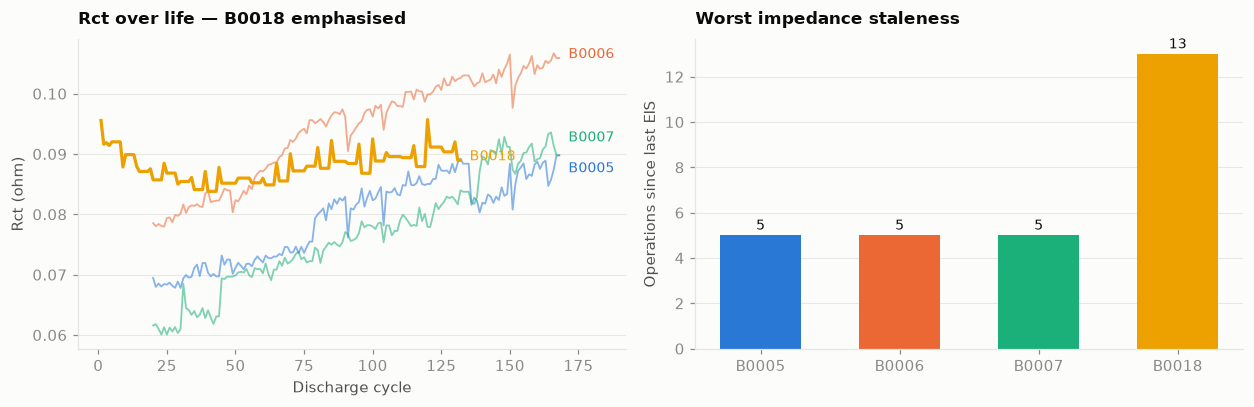

            cycles  imp_max_stale  n_impedance
battery_id                                    
B0005          168            5.0          149
B0006          168            5.0          149
B0007          168            5.0          149
B0018          132           13.0          132


In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.8))

RCT_LABEL = {"B0005": (6, -11), "B0006": (6, 0), "B0007": (6, 9), "B0018": (6, 0)}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id").dropna(subset=["rct_ohm"])
    lw = 2.1 if b == "B0018" else 1.2
    al = 1.0 if b == "B0018" else 0.55
    a1.plot(g.cycle_id, g.rct_ohm, color=SERIES[b], lw=lw, alpha=al, label=b)
    a1.annotate(b, (g.cycle_id.iloc[-1], g.rct_ohm.iloc[-1]), textcoords="offset points",
                xytext=RCT_LABEL[b], fontsize=9, color=SERIES[b])
style(a1, "Rct over life — B0018 emphasised", "Discharge cycle", "Rct (ohm)")
a1.set_xlim(right=a1.get_xlim()[1] * 1.09)

summary = cyc.groupby("battery_id").agg(
    cycles=("cycle_id", "size"),
    imp_max_stale=("impedance_age_ops", "max"),
    n_impedance=("re_ohm", "count"),
)
x = np.arange(len(summary))
a2.bar(x, summary.imp_max_stale, width=0.58, color=[SERIES[b] for b in summary.index])
for xi, vv in zip(x, summary.imp_max_stale):
    a2.text(xi, vv + 0.25, f"{vv:.0f}", ha="center", fontsize=9, color=INK)
a2.set_xticks(x); a2.set_xticklabels(summary.index)
style(a2, "Worst impedance staleness", None, "Operations since last EIS")
plt.tight_layout(); plt.show()

print(summary.to_string())

### How to read it

**Left:** B0005, B0006 and B0007 all start near 0.06–0.07 Ω and climb steadily — the
expected impedance-rise signature. B0018 (bold yellow) starts much *higher*, around
0.095 Ω, then **falls** for the first 40 cycles before drifting sideways. It never shows
the clean upward trend the others do. That is why its correlation with capacity nearly
vanishes.

**Right:** B0018's impedance is also far sparser — up to 13 operations between
measurements versus 5 for the others, from only 53 EIS measurements against 278.

### What to do about it

Two competing explanations, and the data here cannot separate them:

1. B0018 is genuinely a different cell — different initial condition or aging path.
2. Its impedance record is partly defective, and the early decline is an artifact.

The distinction matters. Under (1) B0018 is a legitimately hard held-out cell and poor
LOBO performance on it is informative. Under (2) it is contaminated data, and training on
it would inject noise into the other folds.

Phase 4 should resolve this before any model is fitted. Until then it stays in the
dataset, flagged in the report — removing a cell to improve a score, without establishing
cause, is exactly the kind of decision that makes results untrustworthy.

---

# 10. Summary

| # | Finding | Status | Handling |
|---|---|---|---|
| 1 | Discharge records include a relaxation tail (~9%) | resolved | active-segment masking; tail kept as `relax_duration_s`, `v_recovery_v` |
| 2 | Operation ordering differs between batteries | resolved | positional pairing via `merge_asof` on `op_index` |
| 3 | Cycle 1 is a partial charge on all four cells | resolved | `qc_charge_partial` |
| 4 | Five aborted charge operations | resolved | `qc_charge_aborted` |
| 5 | Early-life discharges overshoot the cut-off | **open** | flagged only — Phase 4 must assess |
| 6 | Identical telemetry volumes across three cells | not a bug | verified different values; synchronous testbed |

**Dataset state:** 636 discharge cycles, 606 clean. Three cells with an EOL label
(125 / 109 / 97), one right-censored.

**Validation:** rebuild is byte-identical; 27 tests pass; the expected physical
relationships between charge timing, impedance and capacity all appear with the right
signs.

### Open questions carried into Phase 4

1. **Finding 5** — is early capacity in B0006/B0007 distorted by the deeper discharges?
2. **B0018** — atypical cell, or defective impedance record? Decide before modelling.
3. **57 cycles have no impedance** — drop, impute with indicator, or restrict to cycle ≥ 20?
4. **Regeneration and rest** — examine jointly with cell age rather than in isolation.
5. **Indicator screening** — use Spearman alongside Pearson; the relationships are
   monotone but curved.